In [13]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as p
import numpy as np
import flamingo_analysis as fa 
import flamingo_tangos as ft
import tangos as db

db.init_db('data.db')

def crosscheck(halo_num, f='_inflow'):
    halo = db.get_halo(f"L0200N0360_HYDRO_FIDUCIAL/%8.hdf5/{halo_num}")
    M200m = halo.calculate('M200m()')
    r200m = halo.calculate('r200m')/1000
    fa.make_entropy_radius_histogram(halo['gas_entropy_radius_histogram' + f], normed=True)
    entropy_reported = db.get_halo(f"L0200N0360_HYDRO_FIDUCIAL/%8.hdf5/{halo_num}")['gas_entropy' + f]
    rvals = ft.FlamingoDensityProfileAbsolute(None).plot_x_values(entropy_reported)
    p.plot(rvals, np.log10(entropy_reported),"k--")
    p.title("$M_{{200m}} = 10^{{{:.2f}}} M_{{\\odot}}$".format(np.log10(M200m)))
    p.axvline(np.log10(r200m), color='red', linestyle=':', label=r"$r_{200m}$")

def crosscheck_all(halo_num):
    p.figure(figsize=(15,5))
    p.subplot(131)
    crosscheck(halo_num,'_inflow')
    p.grid()
    p.subplot(132)
    crosscheck(halo_num,'_outflow')
    p.grid()
    p.subplot(133)
    crosscheck(halo_num,'')
    p.grid()
    p.tight_layout()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


<unknown>:432: SyntaxWarning: invalid escape sequence '\,'
<unknown>:432: SyntaxWarning: invalid escape sequence '\,'


<string>:5: RuntimeWarning: invalid value encountered in divide


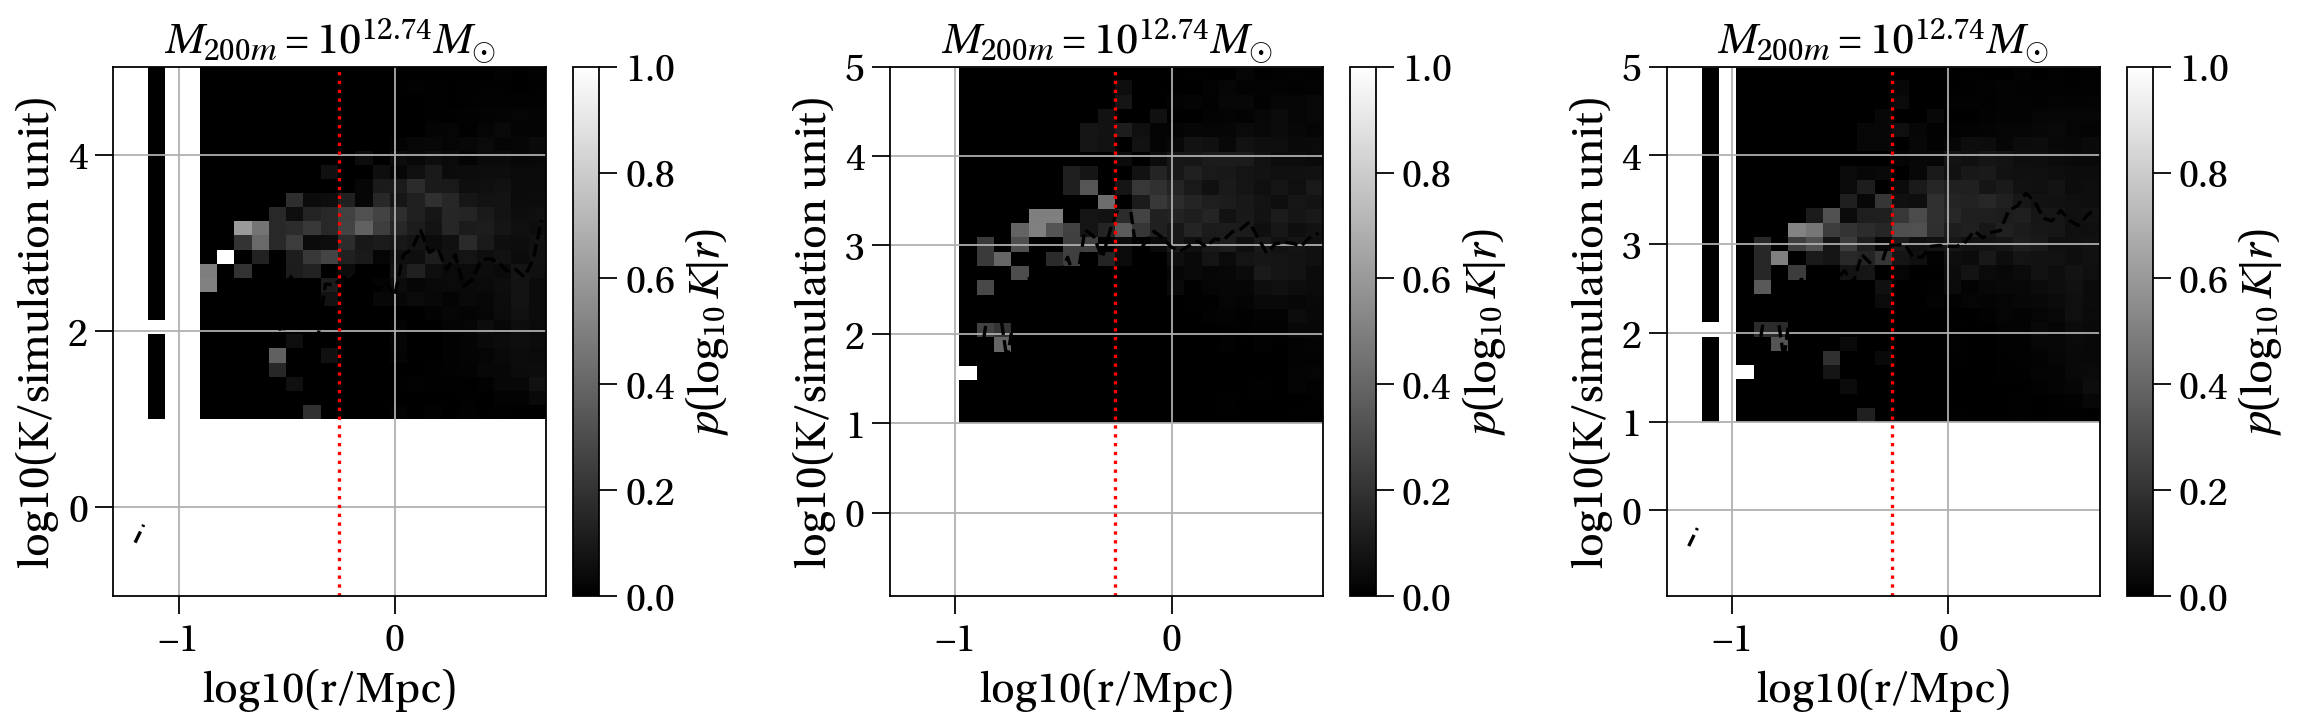

In [14]:
crosscheck_all(2500)

In [15]:
def auto_combine_out_and_inflows():

    fig = p.gcf()

    # Pick the two data axes by title (avoids accidentally grabbing colorbar axes)
    ax_out = next(ax for ax in fig.axes if "outflow" in ax.get_title().lower())
    ax_in  = next(ax for ax in fig.axes if "inflow" in ax.get_title().lower())

    def _axis_data(ax):
        # Prefer true image data if present
        if ax.images:
            arr = np.asarray(ax.images[0].get_array(), dtype=float)
            return np.ma.filled(arr, np.nan)
        raise ValueError("No image data found in axis with title '{}'".format(ax.get_title()))

    img1 = _axis_data(ax_out)
    img2 = _axis_data(ax_in)

    # Match shapes
    hh = min(img1.shape[0], img2.shape[0])
    ww = min(img1.shape[1], img2.shape[1])
    img1 = img1[:hh, :ww]
    img2 = img2[:hh, :ww]

    # Normalize each channel independently
    img1 = (img1 - np.nanmin(img1)) / (np.nanmax(img1) - np.nanmin(img1) + 1e-12)
    img2 = (img2 - np.nanmin(img2)) / (np.nanmax(img2) - np.nanmin(img2) + 1e-12)

    rgb = np.zeros((hh, ww, 3), dtype=float)
    rgb[..., 0] = np.nan_to_num(img1)  # red: outflow
    rgb[..., 2] = np.nan_to_num(img2)  # blue: inflow

    ax3 = p.gca()
    src = ax_out  # outflow/inflow share the same geometry

    im = src.images[0]
    extent = im.get_extent()
    ax3.imshow(
        rgb,
        extent=extent,
        origin=im.origin,
        aspect='auto'
    )


    # Copy labels
    ax3.set_xlabel(src.get_xlabel())
    ax3.set_ylabel(src.get_ylabel())
    ax3.set_title("R: outflow, B: inflow")

    p.xlim(extent[0], extent[1])
    p.ylim(extent[2], extent[3])

def make_mass_stacked_entropy_radius_histogram(M_min=12.5, M_max=12.7):

    p.figure(figsize=(15,5))
    p.subplot(131)
    fa.make_entropy_radius_stack(normed=True, restriction='outflow', M_min=M_min, M_max=M_max)
    p.subplot(132)
    fa.make_entropy_radius_stack(normed=True, restriction='inflow', M_min=M_min, M_max=M_max)
    p.subplot(133)
    auto_combine_out_and_inflows()

    p.tight_layout()

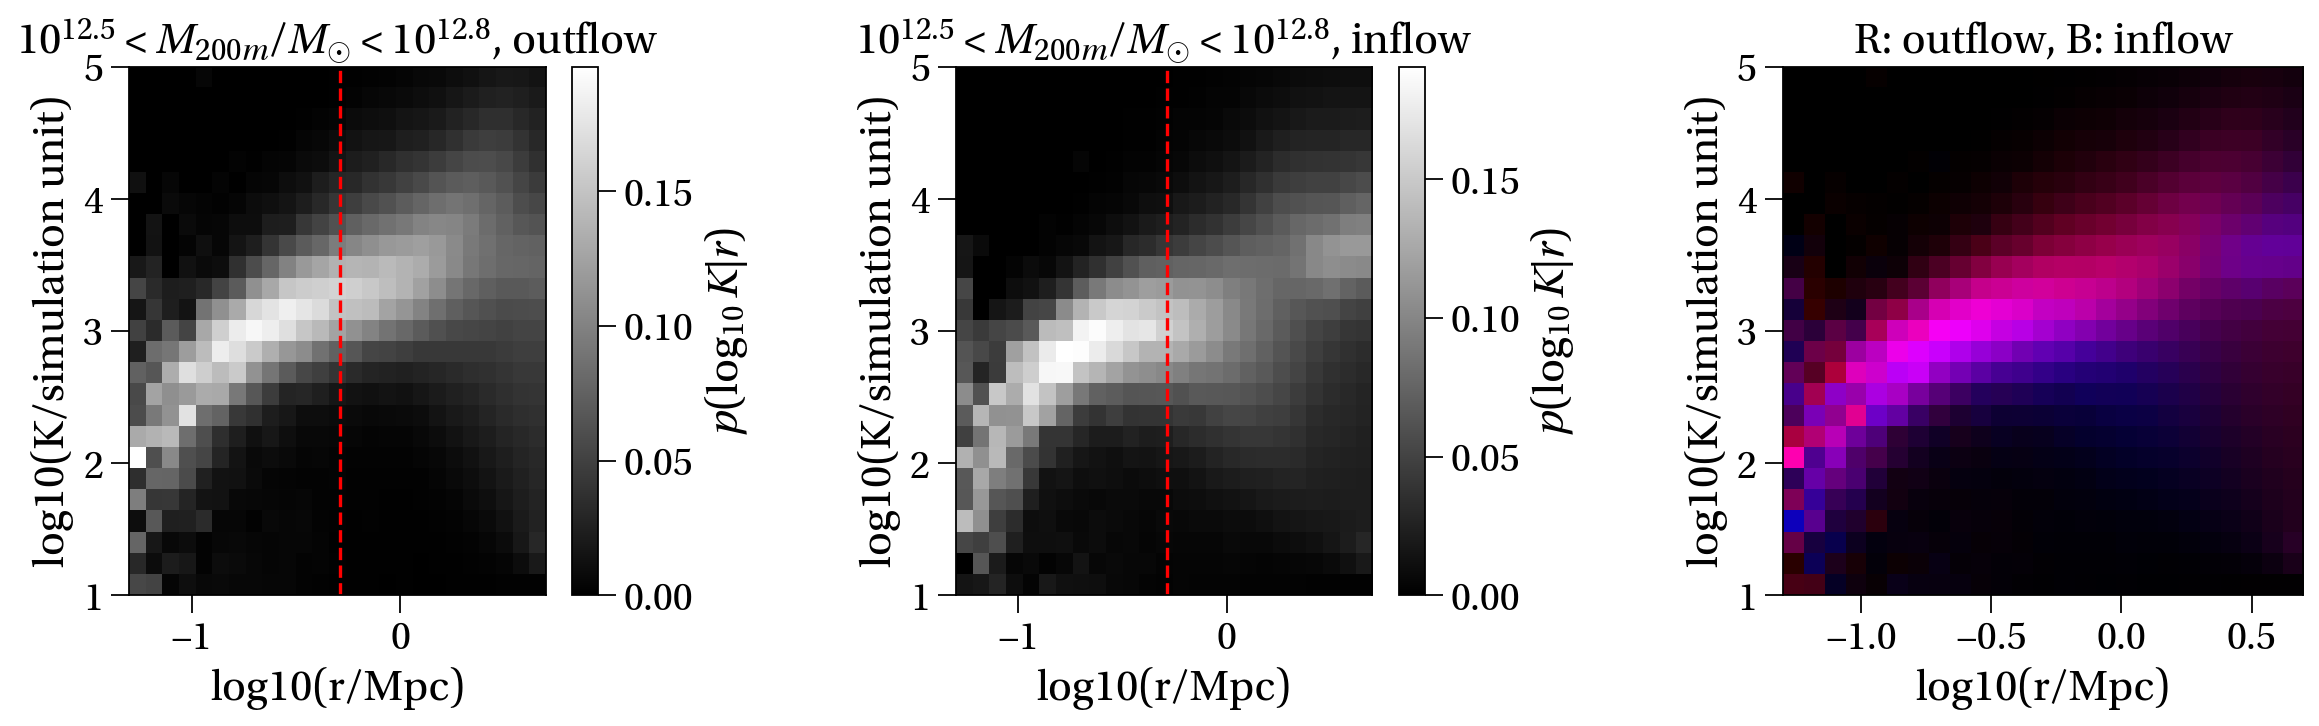

In [20]:
make_mass_stacked_entropy_radius_histogram(12.5, 12.8)

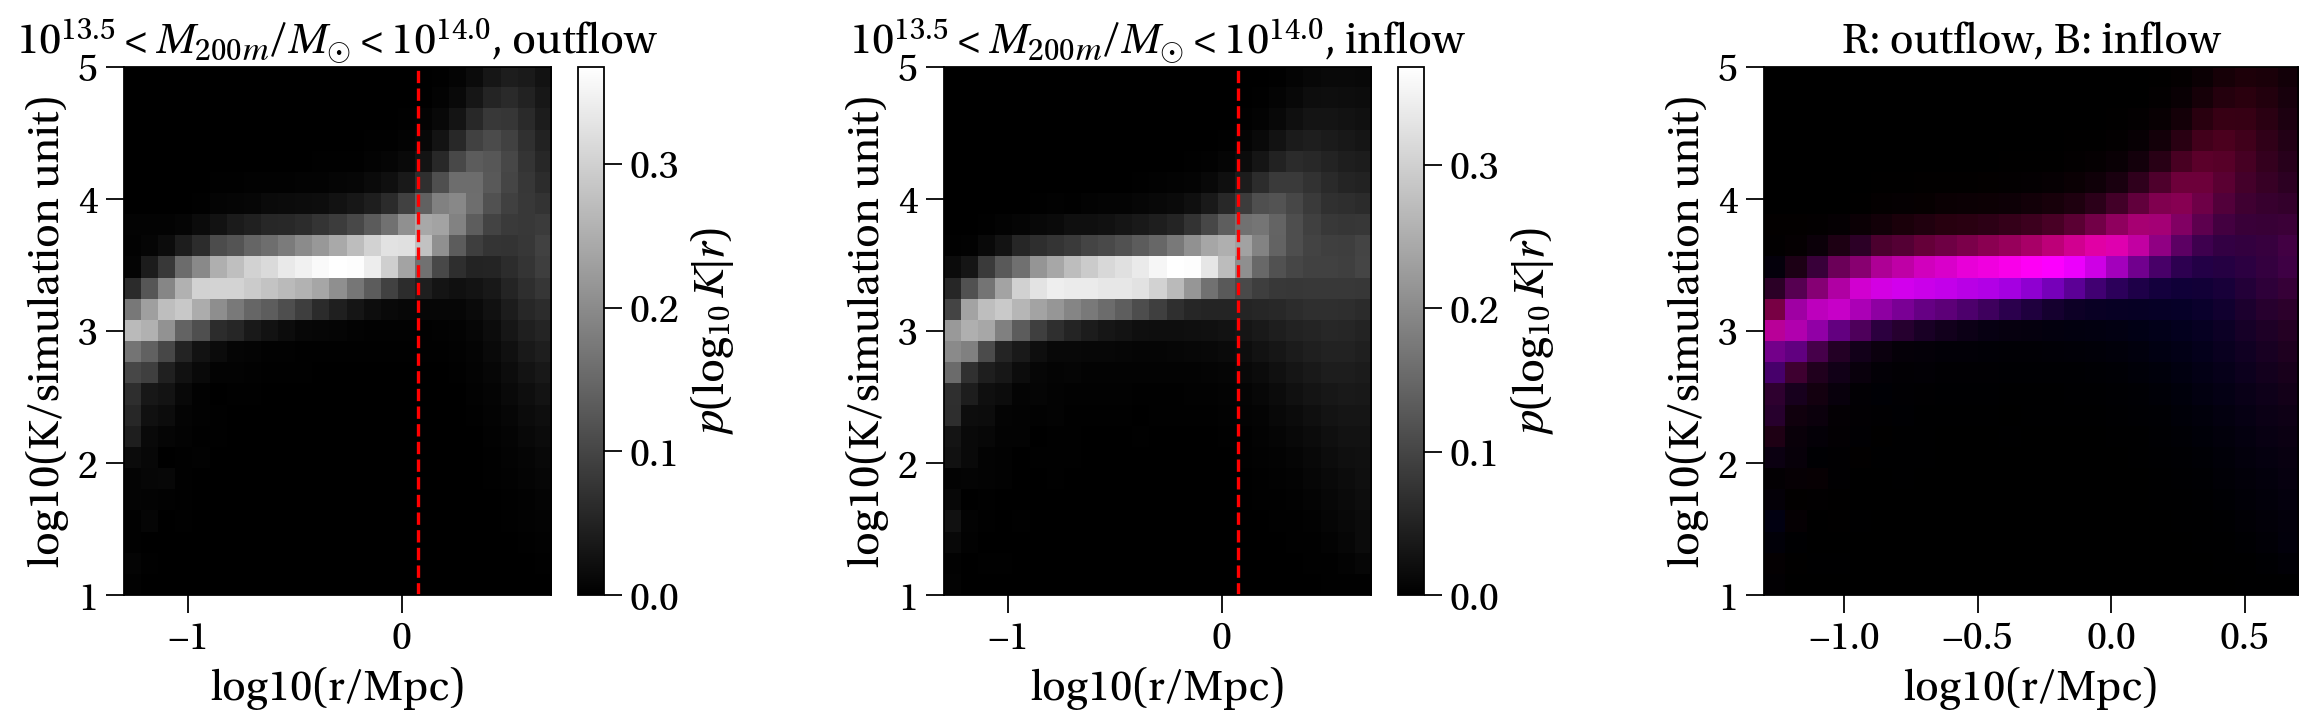

In [19]:
make_mass_stacked_entropy_radius_histogram(M_min=13.5, M_max=14.0)

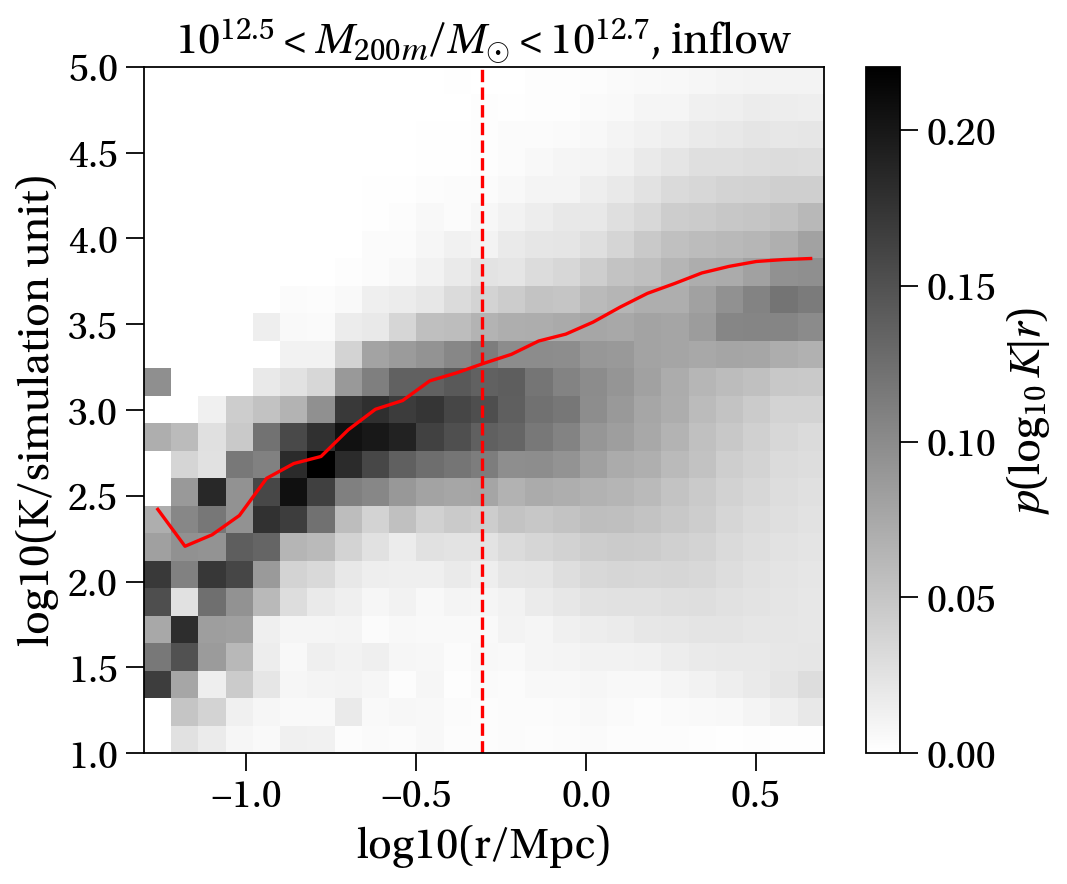

In [58]:
fa.make_entropy_radius_stack(normed=True, restriction='inflow', M_min=12.5, M_max=12.7)

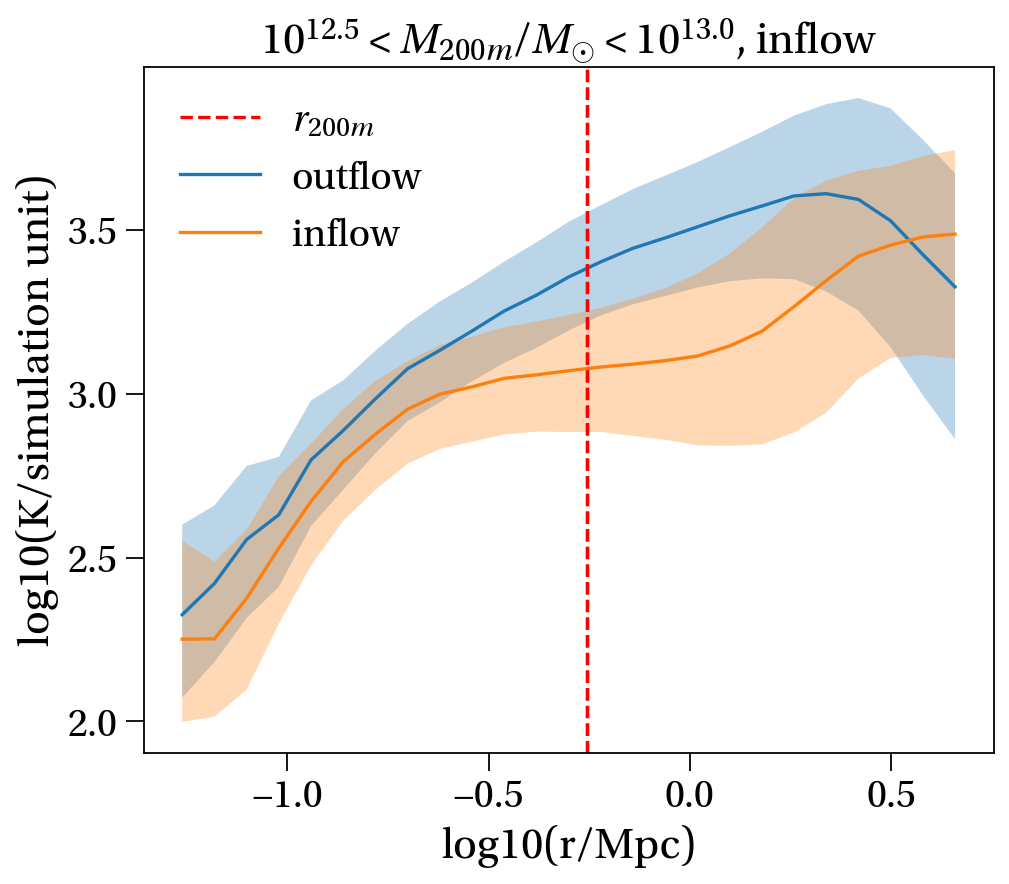

In [39]:
fa.make_entropy_radius_stack_in_and_out()

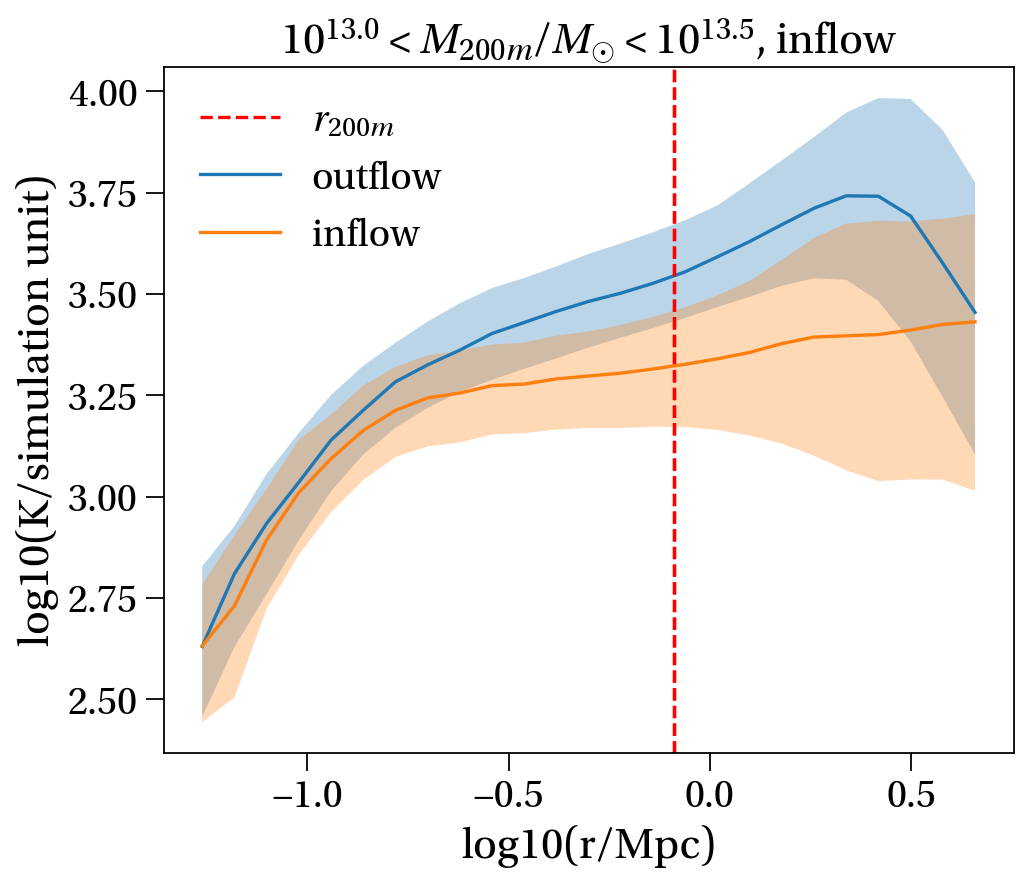

In [40]:
fa.make_entropy_radius_stack_in_and_out(M_min=13.0, M_max=13.5)